# Notebook 03_A: Baseline Models

This notebook trains and evaluates three baseline classifiers using the prepared data from Notebook 02:

- Logistic Regression
- Decision Tree
- Random Forest

The held out test set is used here only for descriptive baseline evaluation. No final model is selected or tuned in this notebook.

Because the thesis prioritises identifying students who are genuinely at risk, recall, F1 score, and PR AUC are reported alongside accuracy, precision, and ROC AUC.

## 1. Imports and project paths

In [1]:
from pathlib import Path
import joblib

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

RANDOM_STATE = 42

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "ml_ready"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "baseline_models"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "results"
    / "figures"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks


## 2. Load prepared train and test data

In [2]:
X_train = pd.read_pickle(
    DATA_DIR / "X_train_prepared.pkl"
)

X_test = pd.read_pickle(
    DATA_DIR / "X_test_prepared.pkl"
)

y_train = pd.read_pickle(
    DATA_DIR / "y_train.pkl"
)

y_test = pd.read_pickle(
    DATA_DIR / "y_test.pkl"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3008, 36)
Testing shape: (752, 36)


## 3. Validate the prepared data

In [3]:
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0

split_summary = pd.DataFrame({
    "split": ["Train", "Test"],
    "students": [len(y_train), len(y_test)],
    "at_risk": [int(y_train.sum()), int(y_test.sum())],
    "at_risk_percentage": [
        round(float(y_train.mean() * 100), 2),
        round(float(y_test.mean() * 100), 2),
    ],
})

display(split_summary)

print("Prepared feature count:", X_train.shape[1])

,split,students,at_risk,at_risk_percentage
0,Train,3008,746,24.80
1,Test,752,187,24.87


Prepared feature count: 36


## 4. Define baseline models

These settings provide reasonable baseline models and are not the final tuned configurations.

Class weighting is used because the at risk class is the minority class.

In [4]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

print("Baseline models created.")

Baseline models created.


## 5. Train and evaluate the baseline models

In [5]:
results = []
trained_models = {}
predictions_by_model = {}
probabilities_by_model = {}

for model_name, model in models.items():

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    ).ravel()

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "f2_score": fbeta_score(
            y_test,
            predictions,
            beta=2,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities,
        ),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    })

    trained_models[model_name] = model
    predictions_by_model[model_name] = predictions
    probabilities_by_model[model_name] = probabilities

print("Baseline training and evaluation completed.")

Baseline training and evaluation completed.


## 6. Compare baseline performance

In [18]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["f1_score", "pr_auc", "recall"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    results_df.round(4)
)

print(
    "Baseline comparison only. "
    "Final model selection is performed later using training only cross validation."
)

,model,accuracy,precision,recall,f1_score,f2_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Random Forest,0.9069,0.7671,0.8984,0.8276,0.8687,0.9666,0.9011,514,51,19,168
1,Decision Tree,0.8989,0.7382,0.9198,0.8190,0.8767,0.9416,0.8161,504,61,15,172
2,Logistic Regression,0.8684,0.6880,0.8610,0.7648,0.8198,0.9407,0.8362,492,73,26,161


Baseline comparison only. Final model selection is performed later using training only cross validation.


## 7. Baseline performance figure

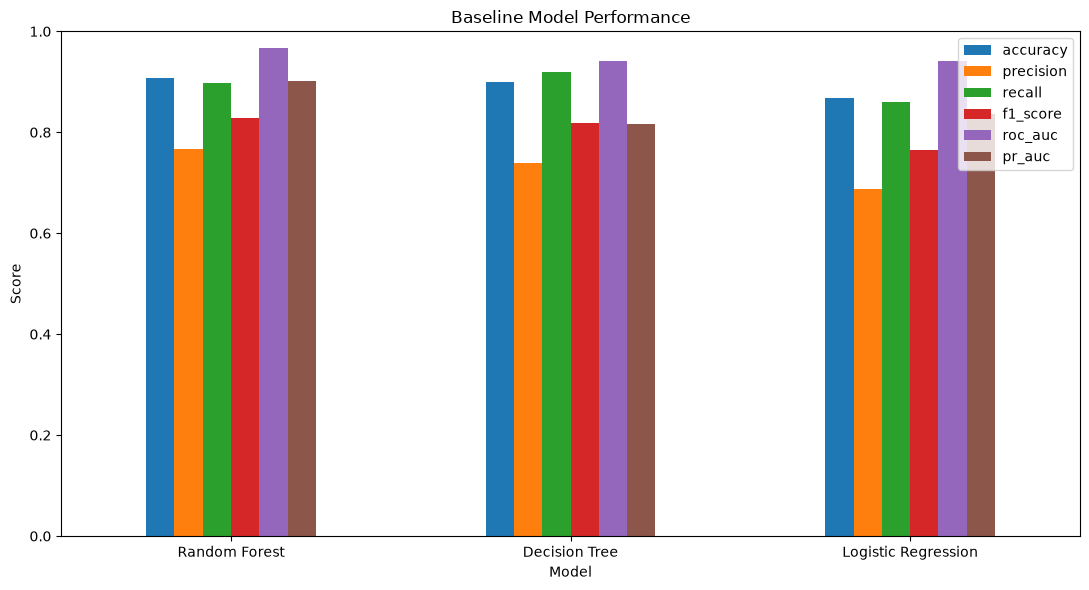

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\baseline_model_performance.png


In [7]:
metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

plot_data = (
    results_df[
        ["model"] + metric_columns
    ]
    .set_index("model")
)

axis = plot_data.plot(
    kind="bar",
    figsize=(11, 6),
)

axis.set_title(
    "Baseline Model Performance"
)

axis.set_xlabel(
    "Model"
)

axis.set_ylabel(
    "Score"
)

axis.set_ylim(
    0,
    1,
)

plt.xticks(rotation=0)
plt.tight_layout()

performance_figure = (
    FIGURES_DIR
    / "baseline_model_performance.png"
)

plt.savefig(
    performance_figure,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", performance_figure)

## 8. Confusion matrices

Confusion matrices are displayed to show the number of at risk students missed and correctly identified by each baseline model.

They are not saved separately because the same counts are already stored in the baseline results table.

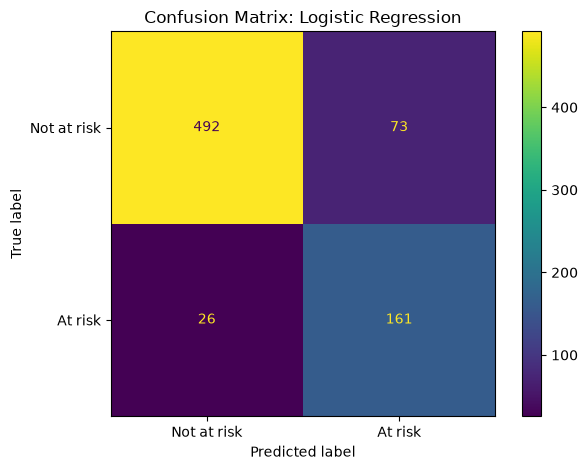

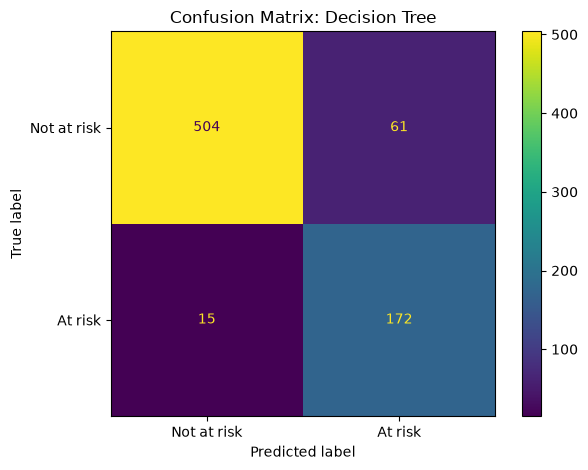

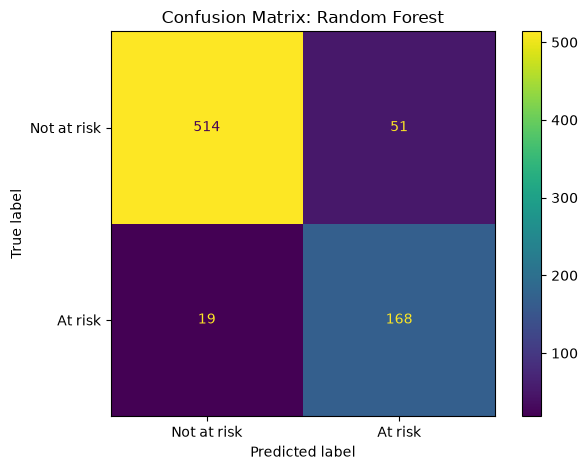

In [8]:
for model_name in models:

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions_by_model[model_name],
        labels=[0, 1],
        display_labels=[
            "Not at risk",
            "At risk",
        ],
        values_format="d",
    )

    plt.title(
        f"Confusion Matrix: {model_name}"
    )

    plt.tight_layout()
    plt.show()

## 9. ROC and precision recall curves

ROC curves show overall class discrimination.

Precision recall curves are particularly useful here because the at risk class is the minority class and recall is an important thesis objective.

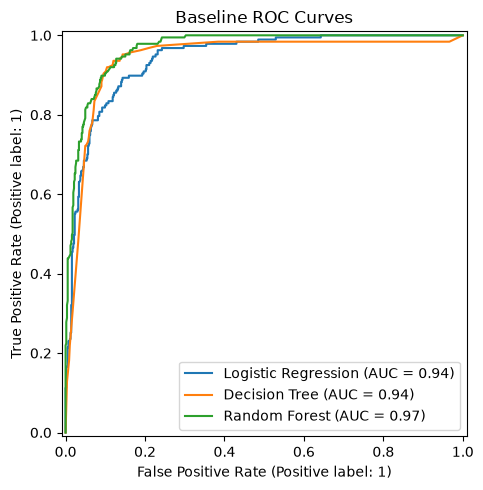

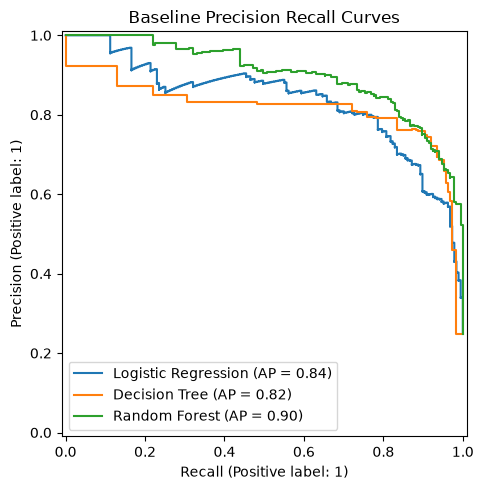

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\baseline_precision_recall_curves.png


In [9]:
roc_figure, roc_axis = plt.subplots(
    figsize=(7, 5)
)

for model_name in models:

    RocCurveDisplay.from_predictions(
        y_test,
        probabilities_by_model[model_name],
        name=model_name,
        ax=roc_axis,
    )

roc_axis.set_title(
    "Baseline ROC Curves"
)

plt.tight_layout()
plt.show()


pr_figure, pr_axis = plt.subplots(
    figsize=(7, 5)
)

for model_name in models:

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities_by_model[model_name],
        name=model_name,
        ax=pr_axis,
    )

pr_axis.set_title(
    "Baseline Precision Recall Curves"
)

plt.tight_layout()

pr_figure_file = (
    FIGURES_DIR
    / "baseline_precision_recall_curves.png"
)

plt.savefig(
    pr_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", pr_figure_file)

## 10. Save only required baseline outputs

Only the baseline results table and the Random Forest baseline model are saved.
It is not the final thesis model.

In [10]:
results_file = (
    RESULTS_DIR
    / "baseline_model_results.csv"
)

results_df.to_csv(
    results_file,
    index=False,
)

rf_baseline_file = (
    RESULTS_DIR
    / "random_forest_baseline.joblib"
)

joblib.dump(
    trained_models["Random Forest"],
    rf_baseline_file,
)

print("Saved:", results_file)
print("Saved:", rf_baseline_file)

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\baseline_models\baseline_model_results.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\baseline_models\random_forest_baseline.joblib


## Notebook 03_A complete